# 2023 Global Prosperity Index Analysis - David Custer - STAT 531

## Table of Contents:
* [Homework 1](#hw1)
    * [Introduction](#intro)
* [Homework 2](#hw2)

## Homework 1 <a id="hw1"></a>

## Introduction <a class="anchor" id="intro"></a>

## Packages

In [ ]:
%pip install --quiet matplotlib notebook numpy pandas plotly scikit-learn seaborn 2>nul
%pip install --no-deps mvlearn

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import plotly.express as px
from mvlearn.embed import GCCA

## Data Wrangling

In [9]:
prosperity_ranks = pd.read_csv(r"C:\Users\anon\Python Files\STAT 531\2023globalpropserity.csv")
display(prosperity_ranks) # We want to extract the relevant political regimes and regions.

,country,code,region,political_regime,prosperity_rank,safety_and_security,personal_freedom,governance,social_capital,investment_environment,enterprise_conditions,infrastructure_and_market_access,economic_quality,living_conditions,health,education,natural_environment
0,Denmark,DNK,Europe,Liberal Democracy,6.00,6,2,3,1,8,8,9,7,2,16,5,5
1,Sweden,SWE,Europe,Liberal Democracy,6.83,10,4,7,4,6,15,7,8,3,9,8,1
2,Norway,NOR,Europe,Liberal Democracy,7.25,3,1,2,3,9,14,20,5,4,7,10,9
3,Finland,FIN,Europe,Liberal Democracy,8.00,15,3,1,7,2,12,10,20,7,15,2,2
4,Switzerland,CHE,Europe,Liberal Democracy,6.75,2,12,4,12,12,1,11,2,5,10,4,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,Somalia,SOM,Africa,Closed Autocracy,153.62,160,141,161,143,153,140,165,165,159,163,158,136
155,Afghanistan,AFG,Asia,Closed Autocracy,154.25,166,148,149,166,154,139,159,152,153,153,157,155
156,Central African Republic,CAF,Africa,Electoral Autocracy,150.38,157,135,155,160,160,149,166,130,167,167,165,93
157,Yemen,YEM,Asia,Closed Autocracy,156.88,165,159,166,157,165,160,156,164,148,136,155,152


In [10]:
pd.set_option("display.max_rows", 10)
prosperity_scores = pd.read_csv(r"C:\Users\anon\Python Files\STAT 531\data.csv")
display(prosperity_scores)

# check for missing values

pd.set_option("display.max_rows", 20)
prosperity_scores.isnull().sum() # no more missing values

,country,region,political_regime,prosperity_score,safety_and_security,personal_freedom,governance,social_capital,investment_environment,enterprise_conditions,infrastructure_and_market_access,economic_quality,living_conditions,health,education,natural_environment
0,Denmark,Europe,Liberal Democracy,84.55,92.59,94.09,89.45,82.56,82.42,79.64,78.79,76.81,95.77,81.07,87.48,73.94
1,Sweden,Europe,Liberal Democracy,83.67,90.97,91.90,86.41,78.29,82.81,75.54,79.67,76.18,95.33,82.28,85.92,78.74
2,Norway,Europe,Liberal Democracy,83.59,93.30,94.10,89.66,79.03,82.24,75.95,75.87,77.25,94.70,82.98,85.68,72.37
3,Finland,Europe,Liberal Democracy,83.47,89.56,91.96,90.41,77.27,84.12,77.25,78.77,70.28,94.46,81.19,88.38,77.99
4,Switzerland,Europe,Liberal Democracy,83.42,95.66,87.50,87.67,69.14,80.81,83.84,78.65,79.71,94.66,82.11,87.72,73.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,Somalia,Africa,Closed Autocracy,34.39,31.91,34.32,23.80,43.50,31.16,41.79,26.75,28.23,32.07,44.38,26.32,48.46
163,Afghanistan,Asia,Closed Autocracy,34.18,20.93,31.02,29.47,31.17,30.25,42.01,29.67,33.75,39.74,50.91,27.11,44.11
164,Central African Republic,Africa,Electoral Autocracy,32.83,35.30,36.83,28.40,36.72,26.32,40.21,25.49,40.34,19.21,31.95,18.62,54.57
165,Yemen,Middle East,Closed Autocracy,32.65,22.60,25.30,18.20,38.44,22.76,33.12,30.93,28.81,41.58,57.45,28.12,44.49


country                             0
region                              0
political_regime                    0
prosperity_score                    0
safety_and_security                 0
personal_freedom                    0
governance                          0
social_capital                      0
investment_environment              0
enterprise_conditions               0
infrastructure_and_market_access    0
economic_quality                    0
living_conditions                   0
health                              0
education                           0
natural_environment                 0
dtype: int64

## Countries in each Region

In [11]:
country_region_df = prosperity_scores[["country", "region"]]
grouped = country_region_df.groupby("region")["country"].apply(list).reset_index()
grouped["country"] = grouped["country"].apply(sorted)
grouped = grouped.sort_values("region")
max_len = max(grouped["country"].apply(len))
data = {region: countries + [""] * (max_len - len(countries)) for region, 
        countries in zip(grouped["region"], grouped["country"])}
regions_df = pd.DataFrame(data)
sorted_regions_df = regions_df.sort_index(axis=1)
pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 1000)
display(sorted_regions_df)

,Africa,Asia,Caribbean,Central America,Europe,Middle East,North America,Oceania,South America
0,Algeria,Afghanistan,Cuba,Belize,Albania,Armenia,Canada,Australia,Argentina
1,Angola,Bangladesh,Dominican Republic,Costa Rica,Austria,Azerbaijan,Mexico,New Zealand,Bolivia
2,Benin,Cambodia,Haiti,El Salvador,Belarus,Bahrain,United States,Papua New Guinea,Brazil
3,Botswana,China,Jamaica,Guatemala,Belgium,Georgia,,,Chile
4,Burkina Faso,Hong Kong,Trinidad and Tobago,Honduras,Bosnia and Herzegovina,Iran,,,Colombia
5,Burundi,India,,Nicaragua,Bulgaria,Iraq,,,Ecuador
6,Cabo Verde,Indonesia,,Panama,Croatia,Israel,,,Guyana
7,Cameroon,Japan,,,Cyprus,Jordan,,,Paraguay
8,Central African Republic,Kazakhstan,,,Czech Republic,Kuwait,,,Peru
9,Chad,Kyrgyzstan,,,Denmark,Lebanon,,,Suriname


## Visualizations

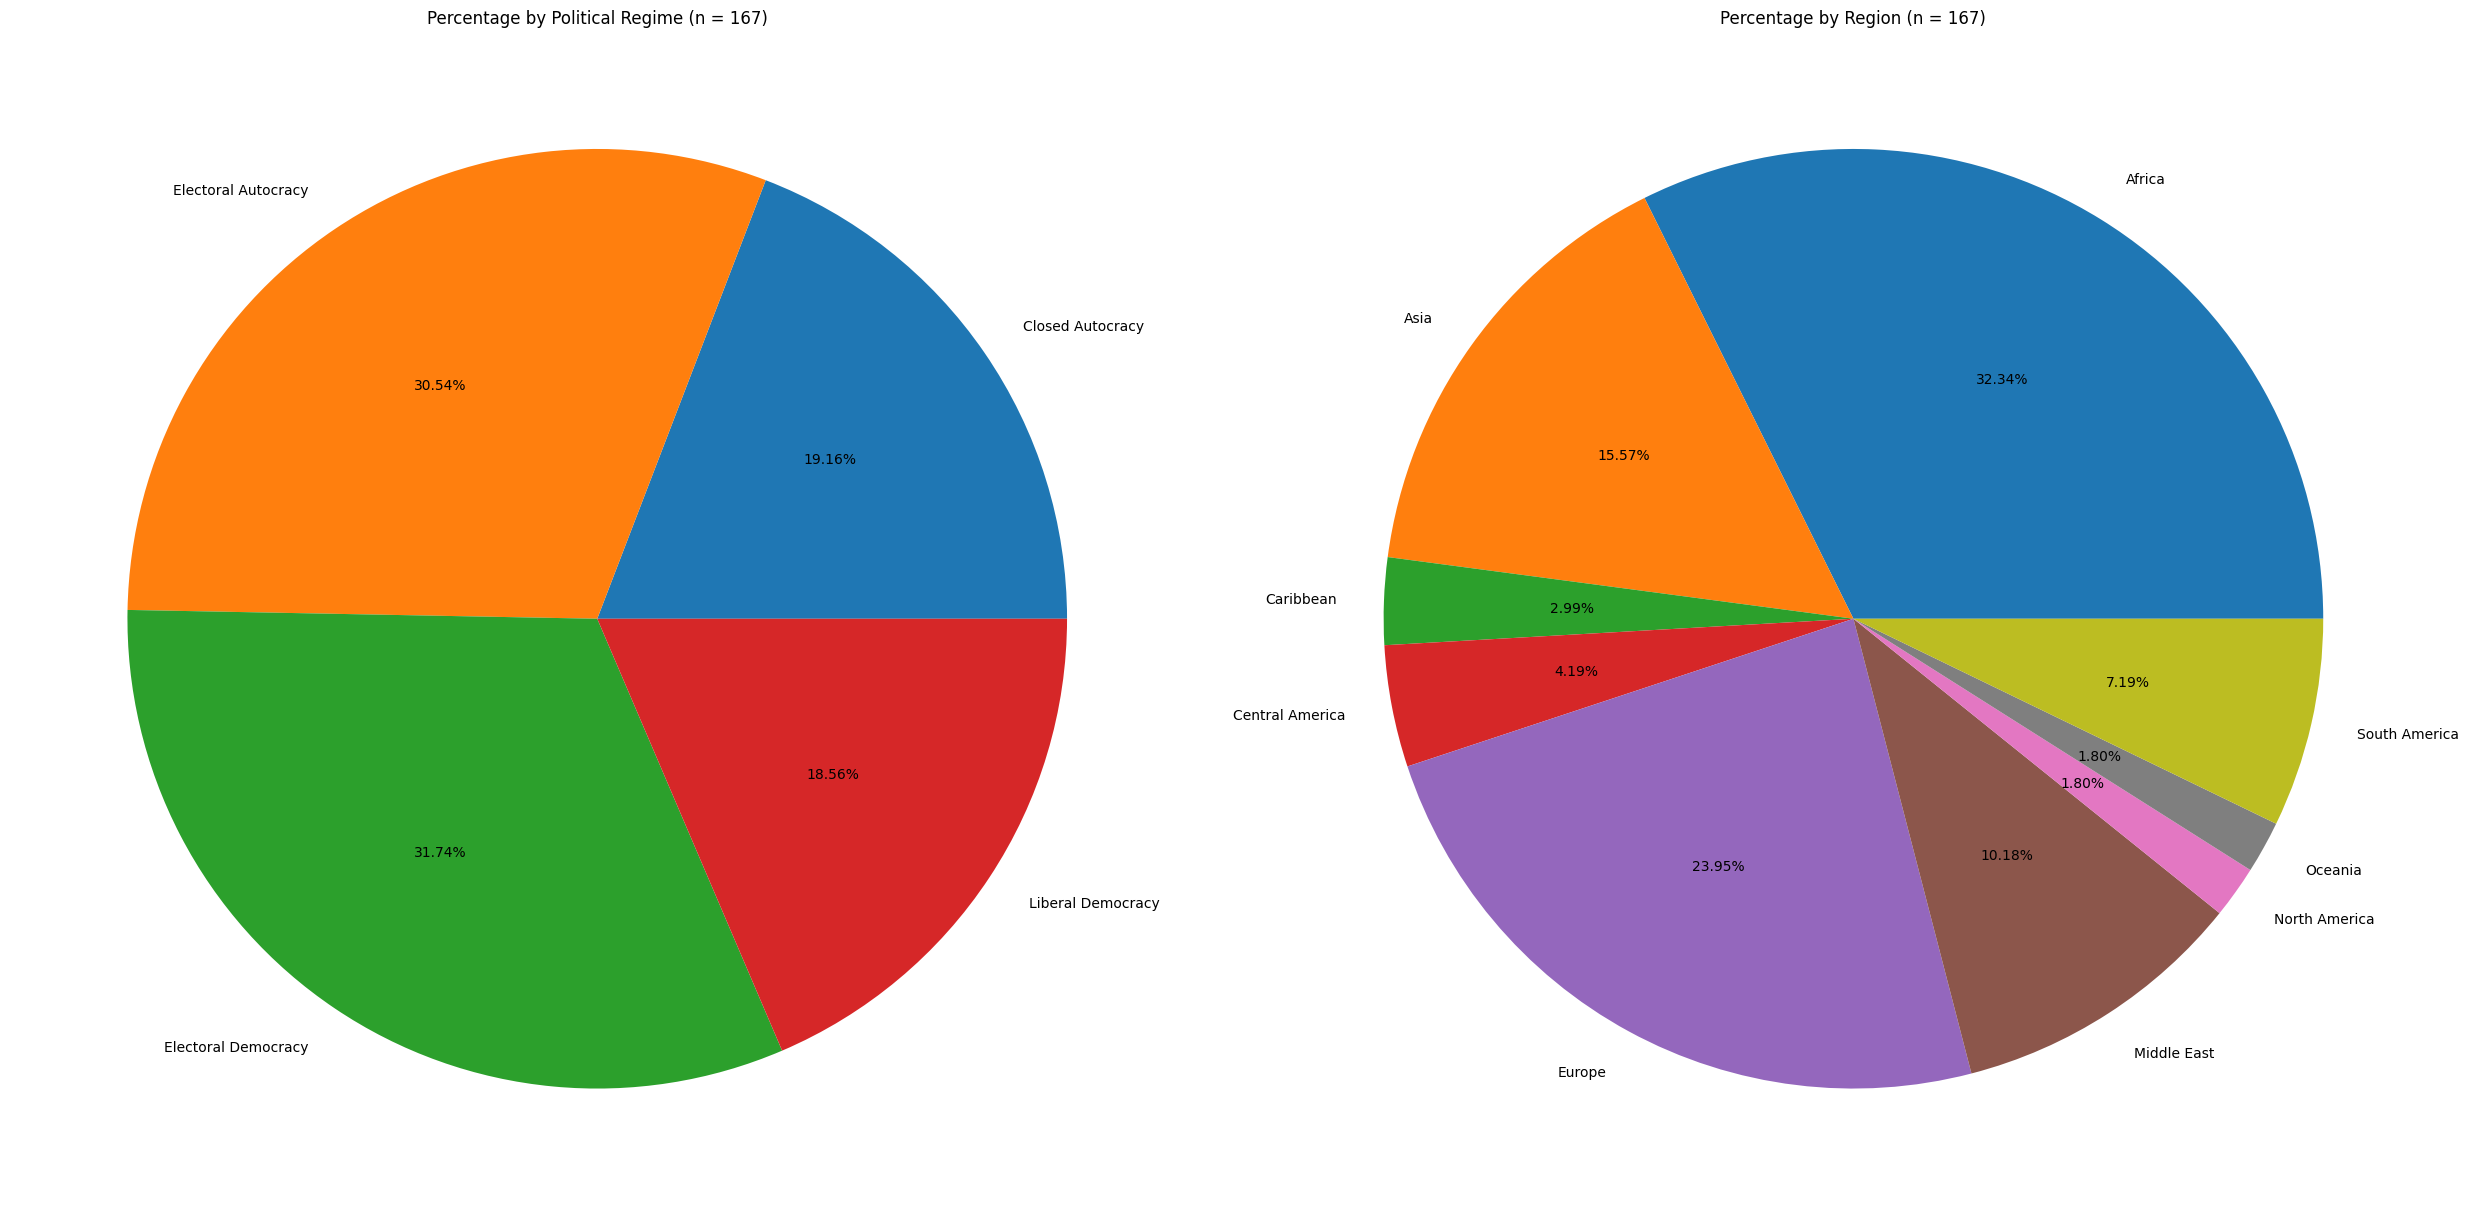

In [12]:
region_coverage = prosperity_scores.groupby("region").size()
political_regime_coverage = prosperity_scores.groupby("political_regime").size()

fig, axes = plt.subplots(1, 2, figsize=(25,20))

political_regime_coverage.plot.pie(autopct = "%.2f%%", ax = axes[0], 
                        title = "Percentage by Political Regime (n = 167)")
region_coverage.plot.pie(autopct = "%.2f%%", ax = axes[1], 
                         title = "Percentage by Region (n = 167)")

plt.tight_layout()
plt.show()

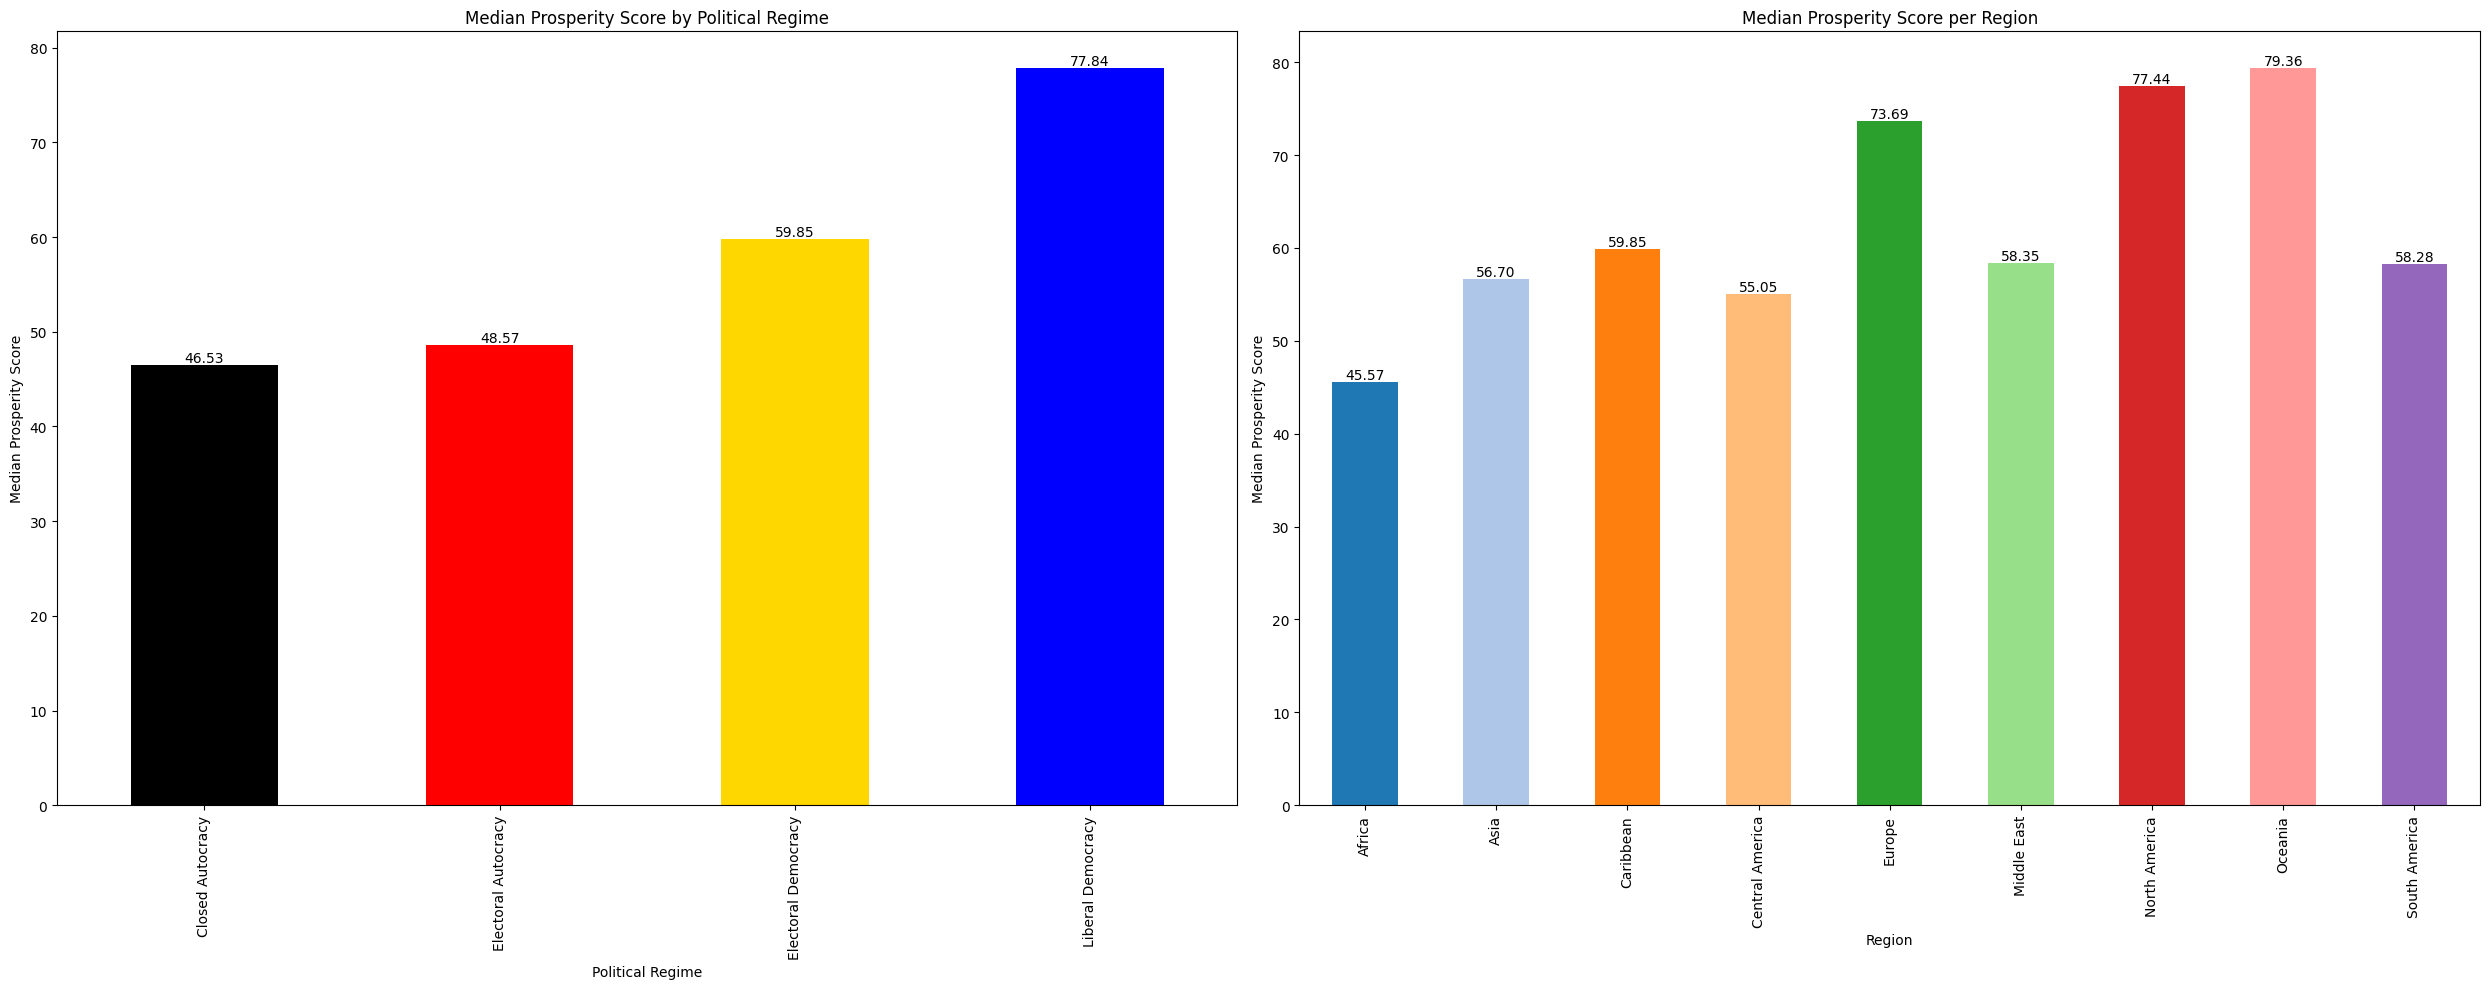

In [13]:
region_median_scores = prosperity_scores.groupby("region")["prosperity_score"].median()
regime_median_scores = prosperity_scores.groupby("political_regime")["prosperity_score"].median()

regime_colors = {
    "Liberal Democracy": (0/255, 0/255, 255/255),       # blue
    "Electoral Democracy": (255/255, 215/255, 0/255),   # yellow
    "Electoral Autocracy": (255/255, 0/255, 0/255),     # red
    "Closed Autocracy": (0/255, 0/255, 0/255)           # black
}
colors = plt.cm.tab20.colors

fig, axes = plt.subplots(1, 2, figsize = (25, 10))

ax_1 = regime_median_scores.plot(kind = "bar", 
                                 color = [regime_colors[regime] for regime in regime_median_scores.index], 
                                 ax = axes[0], grid = False, 
                                 title = "Median Prosperity Score by Political Regime")
ax_1.set_xlabel("Political Regime")
ax_1.set_ylabel("Median Prosperity Score")
for p in ax_1.patches:
    ax_1.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha = "center", va = "center", xytext = (0, 5), textcoords = "offset points")
    
ax_2 = region_median_scores.plot(kind = "bar", color = colors, ax = axes[1], grid = False, 
                                 title = "Median Prosperity Score per Region")
ax_2.set_xlabel("Region")
ax_2.set_ylabel("Median Prosperity Score")
for p in ax_2.patches:
    ax_2.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha = "center", va = "center", xytext = (0, 5), textcoords = "offset points")
    
plt.tight_layout()
plt.show()

## Canonical Correlation Analysis (CCA)

### Scatterplot Matrix

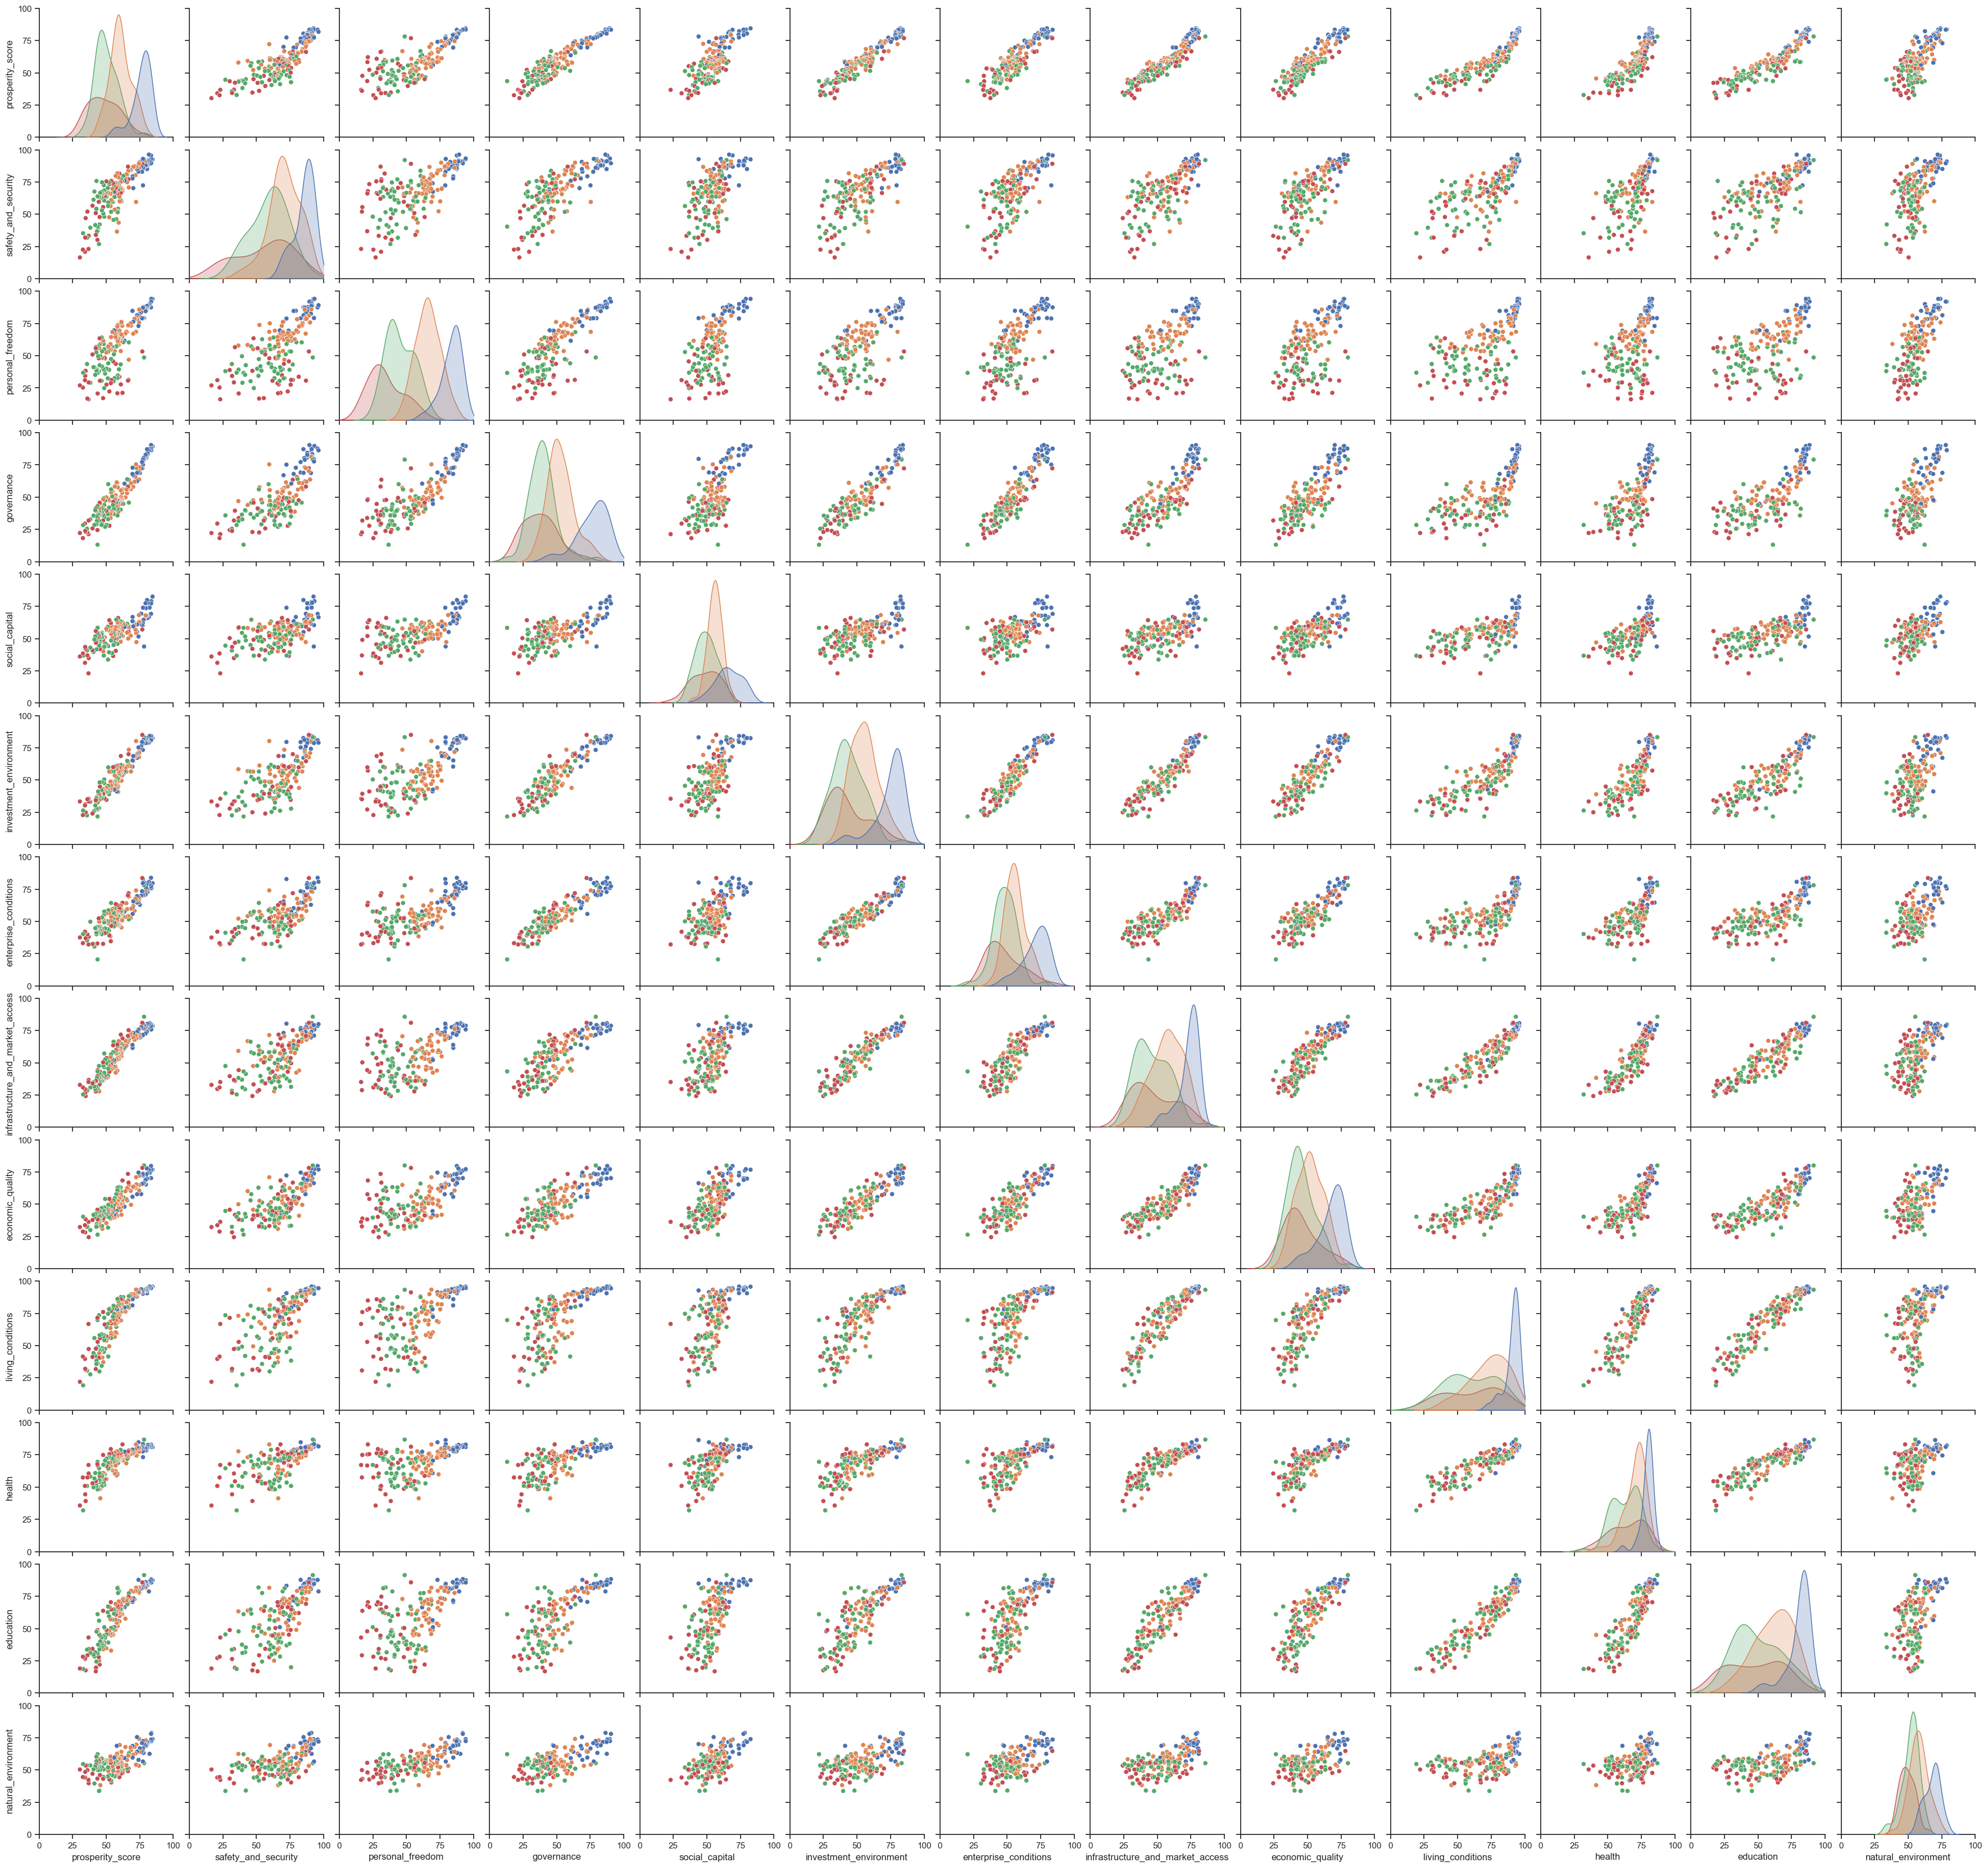

In [14]:
reduced_scores_cca1 = prosperity_scores.drop(columns = ["country", "region"])
sns.set_theme(style = "ticks")
pairplot = sns.pairplot(reduced_scores_cca1, corner = False, 
                        hue = "political_regime")
for ax in pairplot.axes.flatten():
    if ax is not None:
        ax.set_xticks([0, 25, 50, 75, 100])
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
if pairplot._legend:
    pairplot._legend.remove()
plt.subplots_adjust(left = 0, right = 1, top = 1, bottom = 0)
plt.show()

### CCA with Three Groups ** Try a different CCA method for low dimensionality per group **

In [16]:
reduced_scores_cca2 = prosperity_scores.drop(columns=["country", "region", "political_regime", "prosperity_score"])

X = reduced_scores_cca2.iloc[:, np.r_[0:4]]  
Y = reduced_scores_cca2.iloc[:, np.r_[4:8]]  
Z = reduced_scores_cca2.iloc[:, np.r_[8:12]]

gcca = GCCA()
Xs_latents = gcca.fit_transform(Xs)

print(f'The feature sizes are: {[X.shape[1] for X in Xs_latents]}')

NameError: name 'Xs' is not defined

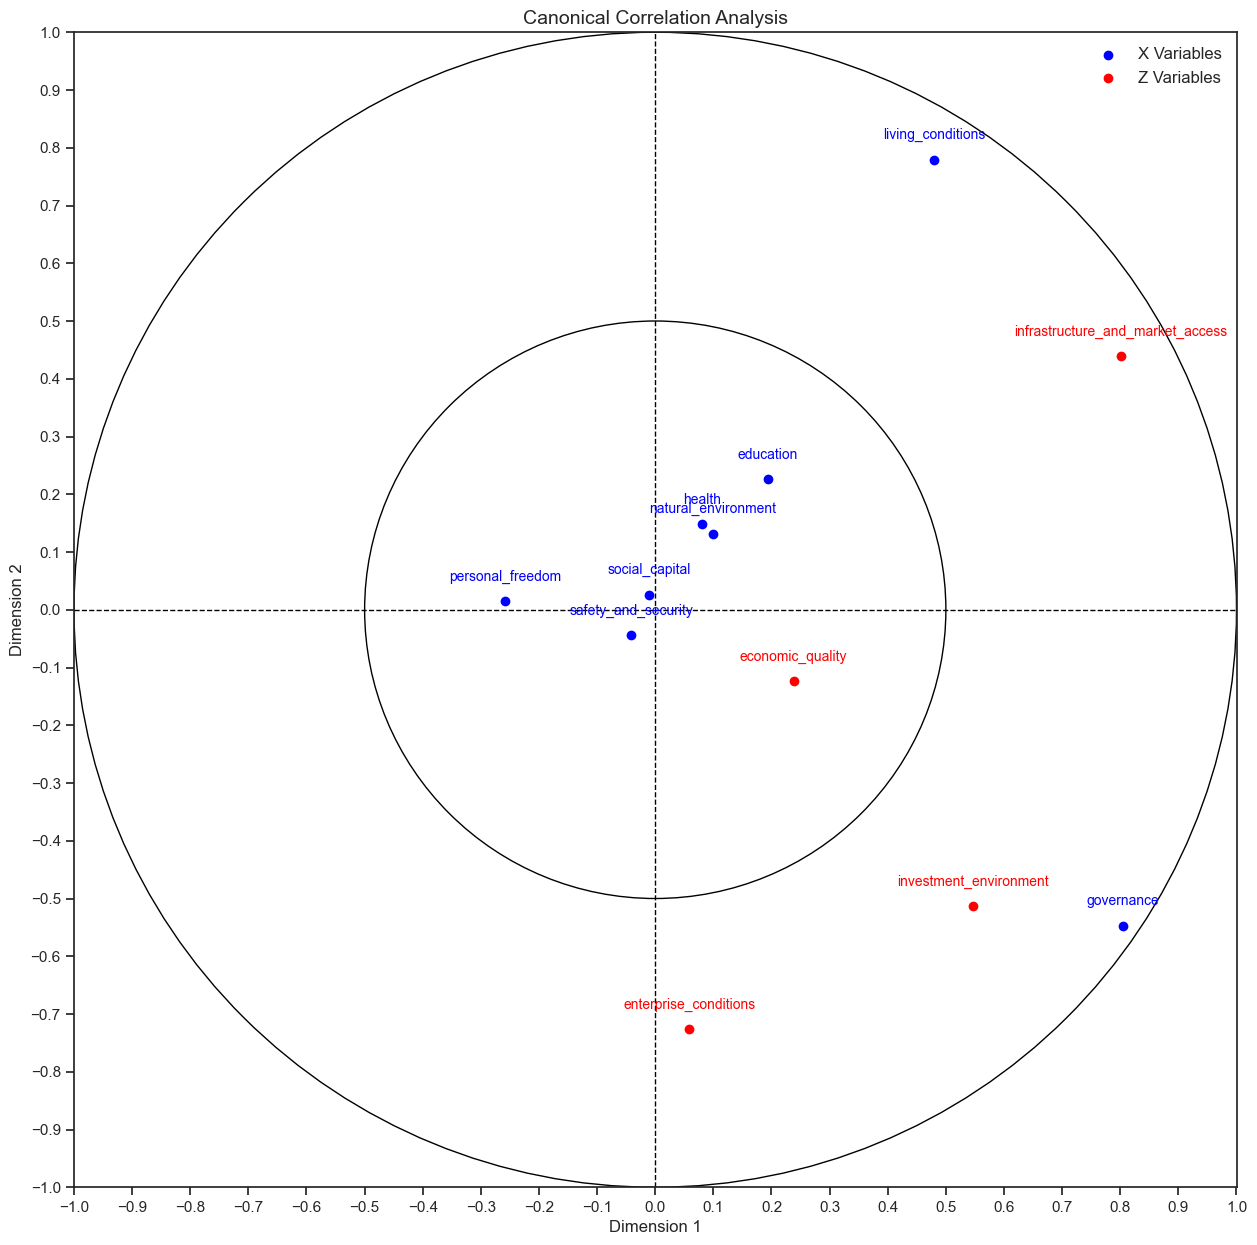

In [ ]:
def plot_cc_cartesian(loadings, d1 = 1, d2 = 2, var_label = True, Xnames = None, Ynames = None):
    X_loadings, Z_loadings = loadings  
    d1 -= 1  
    d2 -= 1  
    fig, ax = plt.subplots(figsize = (15, 15))
    ax.add_patch(plt.Circle((0, 0), 1, color = "black", fill = False))
    ax.add_patch(plt.Circle((0, 0), 0.5, color = "black", fill = False))

    ax.axhline(0, color = "black", linewidth = 1, linestyle = "--")
    ax.axvline(0, color = "black", linewidth = 1, linestyle = "--")
    ax.scatter(X_loadings[:, d1], X_loadings[:, d2], color = "blue", 
               label = "X Variables", alpha = 1)
    ax.scatter(Z_loadings[:, d1], Z_loadings[:, d2], color = "red", 
               label = "Z Variables", alpha = 1)
    if var_label:
        if Xnames is not None:
            for i, name in enumerate(Xnames):
                ax.text(X_loadings[i, d1], X_loadings[i, d2] + 0.03, name, 
                        color = "blue", fontsize = 10, ha = "center", va = "bottom")
        if Ynames is not None:
            for i, name in enumerate(Ynames):
                ax.text(Z_loadings[i, d1], Z_loadings[i, d2] + 0.03, name, 
                        color = "red", fontsize = 10, ha = "center", va = "bottom")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_xticks(np.arange(-1, 1.1, 0.1))
    ax.set_yticks(np.arange(-1, 1.1, 0.1))
    ax.set_xlabel("Dimension 1", fontsize = 12)
    ax.set_ylabel("Dimension 2", fontsize = 12)
    ax.set_title("Canonical Correlation Analysis", fontsize = 14)
    ax.legend(loc = "upper right", fontsize = 12, frameon = False)
    plt.show()

X_loadings = np.array([
    [-0.041294, -0.043354],
    [-0.258467,  0.014397],
    [ 0.804880, -0.546940],
    [-0.010172,  0.026397],
    [ 0.479381,  0.779359],
    [ 0.080436,  0.148759],
    [ 0.193325,  0.226096],
    [ 0.099514,  0.132000]
])

Z_loadings = np.array([
    [ 0.546272, -0.513260],
    [ 0.058335, -0.726687],
    [ 0.800922,  0.439651],
    [ 0.238135, -0.123275]
])

X_var_names = [
    "safety_and_security", "personal_freedom", "governance", "social_capital",
    "living_conditions", "health", "education", "natural_environment"
]

Z_var_names = [
    "investment_environment", "enterprise_conditions",
    "infrastructure_and_market_access", "economic_quality"
]

plot_cc_cartesian((X_loadings, Z_loadings), var_label = True, 
                  Xnames = X_var_names, Ynames = Z_var_names)

## Dimensionality Reduction via Principal Components Analysis (PCA)

The continuous variables in the dataset are all scaled out of 100, so, PCA using the covariance instead of the correlation matrix is appropriate.
We need to drop the categorical variables "region" and "political_regime" to continue due to assumptions under PCA. We removed "country" as well.

### Scree Plot

,PC 1,PC 2,PC 3,PC 4,PC 5,PC 6,PC 7,PC 8,PC 9
λ,0.767191,0.098511,0.038451,0.033186,0.017663,0.011638,0.008667,0.008554,0.005576


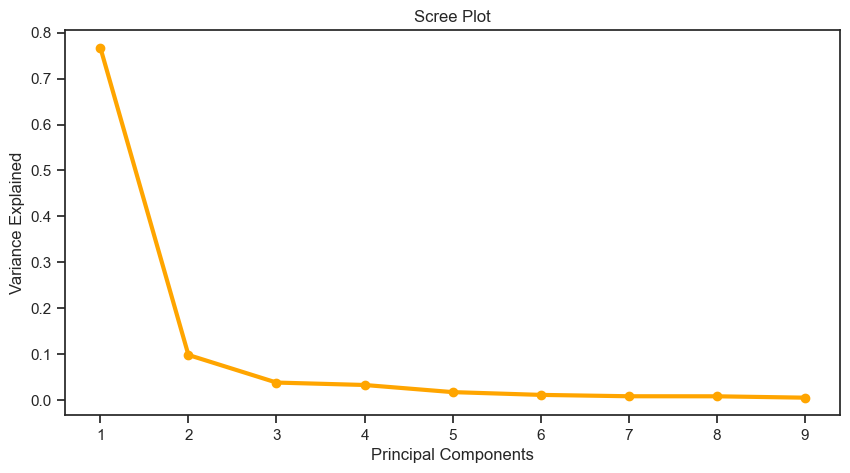

0.904151


In [17]:
reduced_scores_pca = prosperity_scores.drop(columns=["country", "region", "political_regime", "prosperity_score"])
pca = PCA(n_components =  9)
pca_fit = pca.fit_transform(reduced_scores_pca)
pd.set_option("display.width", 1000)
lambda_values = pd.DataFrame([pca.explained_variance_ratio_], 
                             columns = ["PC 1", "PC 2", "PC 3", "PC 4", "PC 5", 
                                        "PC 6", "PC 7", "PC 8", "PC 9"], 
                             index = ["λ"])
lambda_values = lambda_values.style.set_properties(**{"text-align": "right"})
display(lambda_values)
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, pca.n_components_ + 1), pca.explained_variance_ratio_, 
         "o-", linewidth = 3, color = "orange")
plt.title("Scree Plot")
plt.xticks(np.arange(1, 10))
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.show()
print(np.sum(0.76719+0.09851+0.038451))

### PC Loadings

In [18]:
loadings = pd.DataFrame(pca.components_.T, 
                        columns = ["PC 1", "PC 2", "PC 3", "PC 4", "PC 5",
                                   "PC 6", "PC 7", "PC 8", "PC 9"], 
                        index = reduced_scores_pca.columns)

print(loadings.iloc[:, :3])

                                      PC 1      PC 2      PC 3
safety_and_security               0.303253  0.145881  0.477957
personal_freedom                  0.314171  0.687426  0.262571
governance                        0.341139  0.286297 -0.319125
social_capital                    0.161509  0.073394  0.083615
investment_environment            0.332258 -0.015425 -0.395671
enterprise_conditions             0.236961  0.080690 -0.468088
infrastructure_and_market_access  0.313744 -0.198092 -0.148488
economic_quality                  0.253776 -0.094548 -0.228359
living_conditions                 0.373525 -0.383457  0.296612
health                            0.198136 -0.239559  0.086326
education                         0.377674 -0.348467  0.197617
natural_environment               0.126783  0.195001  0.097164


### PC Scores

,PC1,PC2,PC3
0,92.057623,17.515008,-4.607455
1,88.520649,15.496347,-3.433577
2,89.138830,17.942185,-3.156838
3,88.665596,16.847366,-5.230212
4,89.134855,12.082003,-7.620004
...,...,...,...
162,-85.874357,8.110889,-11.422438
163,-84.325613,-1.738557,-19.242175
164,-92.287980,21.985625,-16.917134
165,-91.327499,-11.054467,-6.328751


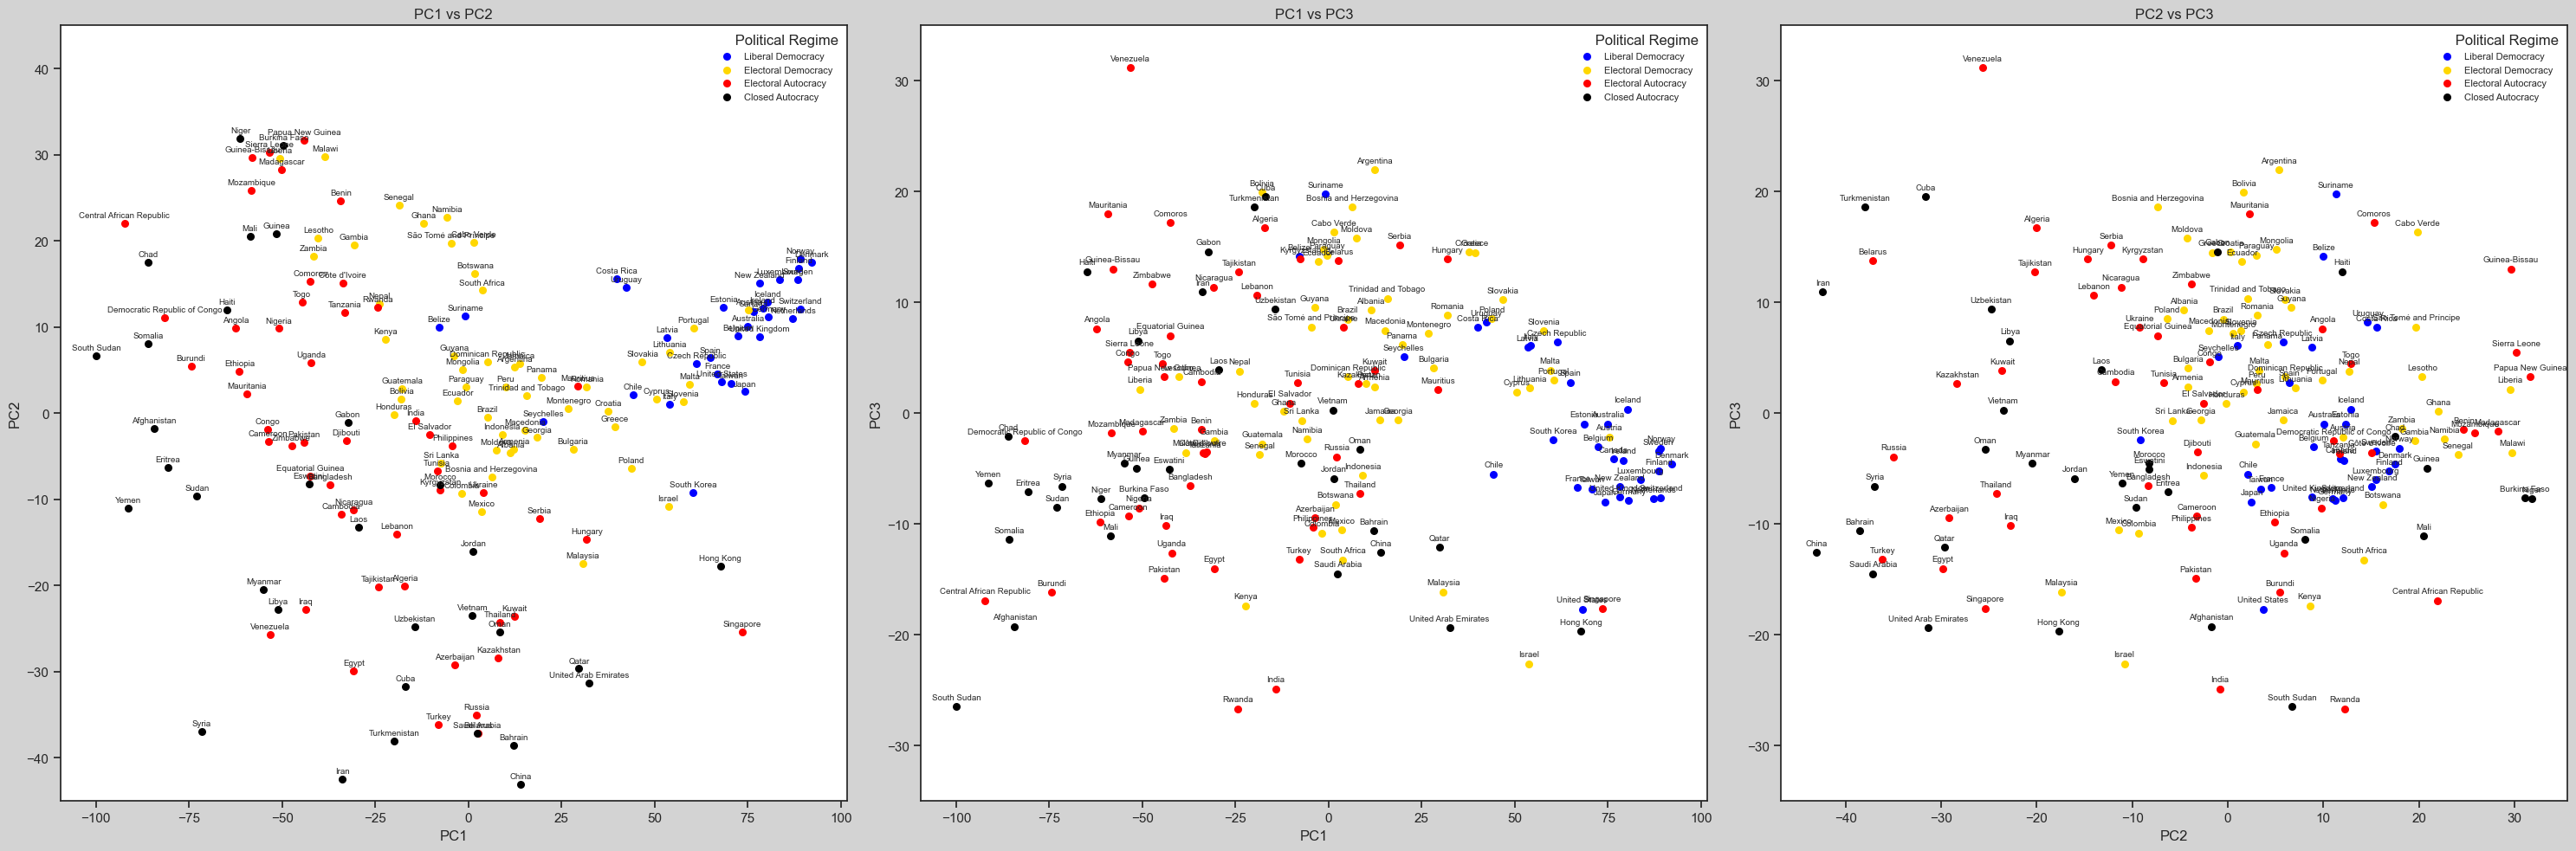

In [19]:
pc_scores = pd.DataFrame(data = pca_fit[:, :3], columns=["PC1", "PC2", "PC3"])
display(pc_scores)
pc_scores["Country"] = prosperity_scores["country"]
pc_scores["Region"] = prosperity_scores["region"]
pc_scores["Political Regime"] = prosperity_scores["political_regime"]

fig, axes = plt.subplots(1, 3, figsize = (30, 10), facecolor = "lightgray")
def plot_scatter(ax, x_col, y_col, xlabel, ylabel, title):
    
    for regime in regime_colors.keys():
        subset = pc_scores[pc_scores["Political Regime"] == regime]
        ax.scatter(subset[x_col], subset[y_col], alpha = 1, s = 30, 
                   label = regime, color = regime_colors[regime])
    for i, txt in enumerate(pc_scores["Country"]):
        ax.text(pc_scores[x_col][i], pc_scores[y_col][i] + 0.5, txt, 
                fontsize = 7, ha = "center", va = "bottom")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    legend = ax.legend(title = "      Political Regime", fontsize = 8, 
                       loc = "upper right", frameon = False)
    legend.get_frame().set_facecolor("lightgray")
    

# Plot PC1 vs PC2

plot_scatter(axes[0], "PC1", "PC2", "PC1", "PC2", "PC1 vs PC2")
axes[0].set_ylim(-45, 45)

# Plot PC1 vs PC3

plot_scatter(axes[1], "PC1", "PC3", "PC1", "PC3", "PC1 vs PC3")
axes[1].set_ylim(-35, 35)

# Plot PC2 vs PC3

plot_scatter(axes[2], "PC2", "PC3", "PC2", "PC3", "PC2 vs PC3")
axes[2].set_ylim(-35, 35)

plt.tight_layout()
plt.show()

### Interactive 3-D Plot of PC Scores

In [ ]:
import plotly.io as pio
from IPython.display import IFrame, display, HTML

fig = px.scatter_3d(
    pc_scores, 
    x = "PC1", 
    y = "PC2", 
    z = "PC3", 
    text = "Country", 
    color = "Region",  
    opacity = 1,
    title = "Interactive 3D PCA Scatter Plot"
)

fig.update_traces(marker = dict(size = 4))
fig.update_layout(
    height = 1000, width = 1000,
    scene = dict(
        xaxis_title = "PC1",
        yaxis_title = "PC2",
        zaxis_title = "PC3"
    ),
    legend = dict(
        title = dict(text = "       Region", side = "top")
    )
)

html_filename = "pca_3d_plot_embedded.html"
pio.write_html(fig, file = html_filename, full_html = True, include_plotlyjs = "cdn")

display(HTML(f"""
    <div style="display: flex; justify-content: center;">
        <iframe src="{html_filename}" width="1100" height="1100"></iframe>
    </div>
"""))


## Homework 2 <a id="hw2"></a>